# Import and Filter Data

## From Challenge 2015 Dataset

In [29]:
import numpy as np
import pandas as pd

# Get Challenge 2015 dataset
with_ppg=[]
import os
for dirname, _, filenames in os.walk('/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/'):
    for filename in filenames:
        if(filename!="ALARMS"):
            if("PLETH" in pd.read_csv(dirname+filename).columns):
                with_ppg.append(filename[0:-4])

# Remove samples with asystole
df=pd.read_csv("/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/ALARMS", names=["Sample", "Label", "TrueAlarm"])
df_relevant=df.loc[df["Label"]!="Asystole"].copy()

# Only include samples with PPG
df_filtered=df_relevant.loc[df_relevant["Sample"].isin(with_ppg)].copy()

# Add path column
df_filtered["Path"]=["/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/"+x+".csv" for x in df_filtered["Sample"]]



In [30]:
v_fib_paths=df_filtered.loc[(df_filtered["Label"]=="Ventricular_Flutter_Fib") & (df_filtered["TrueAlarm"]==1), "Path"].values
v_tachy_paths=df_filtered.loc[(df_filtered["Label"]=="Ventricular_Tachycardia") & (df_filtered["TrueAlarm"]==1), "Path"].values
brady_paths=df_filtered.loc[(df_filtered["Label"]=="Bradycardia") & (df_filtered["TrueAlarm"]==1), "Path"].values
tachy_paths=df_filtered.loc[(df_filtered["Label"]=="Tachycardia") & (df_filtered["TrueAlarm"]==1), "Path"].values
pd.read_csv(v_fib_paths[0])

,II,V,PLETH
0,-861,190,-596
1,-868,183,-666
2,-700,135,-629
3,-674,118,-686
4,-587,92,-715
...,...,...,...
74995,2429,-3239,0
74996,2278,-3276,0
74997,2104,-3295,0
74998,1899,-3319,0


In [31]:
# For downsampling 250 Hz to 125 Hz for consistency
def downsample(signal_in, original_fs=250, target_fs=125):
    if original_fs == target_fs:
        return signal_in  # No downsampling needed
    
    # Design a low-pass filter (FIR or IIR)
    nyquist = target_fs / 2  # Nyquist frequency for new sampling rate
    b, a = signal.butter(4, nyquist / (original_fs / 2), btype='low', analog=False)

    # Apply filter
    filtered_signal = signal.filtfilt(b, a, signal_in)

    # Downsample (take every 2nd sample)
    downsampled_signal = filtered_signal[::2]

    return downsampled_signal

## From PERform AFib Dataset

In [32]:
afib_paths=[]
healthy_paths=[]
afib_samples=[]
healthy_samples=[]

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_af_csv/mimic_perform_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            afib_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            afib_samples.append(filename_split[2]+"_"+filename_split[3])

for dirname, _, filenames in os.walk('/kaggle/input/mimic-perform-af-dataset/mimic_perform_non_af_csv/mimic_perform_non_af_csv'):
    for filename in filenames:
        if("csv" in filename):
            healthy_paths.append(dirname+"/"+filename)
            filename_split=filename.split("_")
            healthy_samples.append(filename_split[2]+"_"+filename_split[3]+"_"+filename_split[4])

afib_df=pd.DataFrame({"Sample":afib_samples,
        "Label":19*["Atrial_Fibrillation"],
        "TrueAlarm":19*[True],
        "Path":afib_paths})

healthy_df=pd.DataFrame({"Sample":healthy_samples,
        "Label":16*["Healthy"],
        "TrueAlarm":16*[True],
        "Path":healthy_paths})

df_filtered=pd.concat([df_filtered, afib_df, healthy_df])

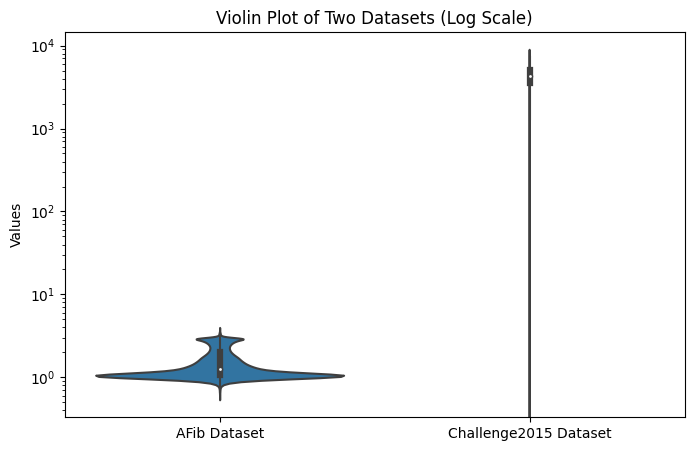

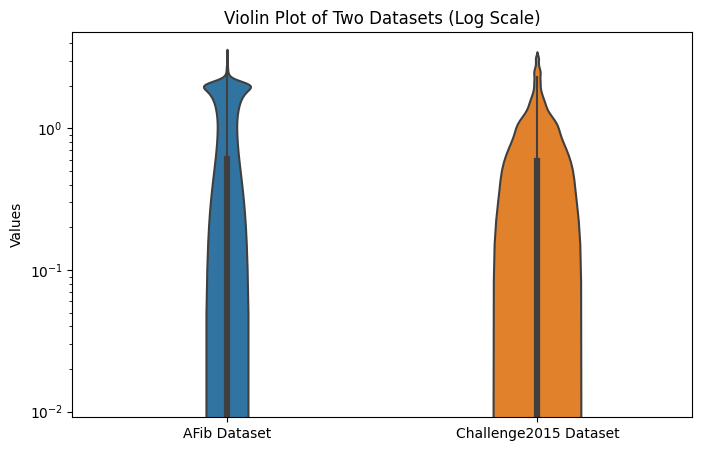

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


data1=pd.read_csv("/kaggle/input/mimic-perform-af-dataset/mimic_perform_non_af_csv/mimic_perform_non_af_csv/mimic_perform_non_af_002_data.csv")["PPG"]
data2=pd.read_csv("/kaggle/input/challenge2015-reducing-false-arrhythmia/Challenge2015_csv/t356s.csv")["PLETH"]

# Combine data into a list
#all_data = [(data1-np.mean(data1))/np.std(data1), (data2-np.mean(data2))/np.std(data2)]
all_data=[data1, data2]
# Create the violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=all_data)

# Customize plot
plt.xticks([0, 1], ['AFib Dataset', 'Challenge2015 Dataset'])
plt.ylabel('Values')
plt.yscale('log')  # Set log scale for y-axis
plt.title('Violin Plot of Two Datasets (Log Scale)')

# Show plot
plt.show()

all_data = [(data1-np.mean(data1))/np.std(data1), (data2-np.mean(data2))/np.std(data2)]
# Create the violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=all_data)

# Customize plot
plt.xticks([0, 1], ['AFib Dataset', 'Challenge2015 Dataset'])
plt.ylabel('Values')
plt.yscale('log')  # Set log scale for y-axis
plt.title('Violin Plot of Two Datasets (Log Scale)')

# Show plot
plt.show()


## Show Number of Waveforms Per Condition

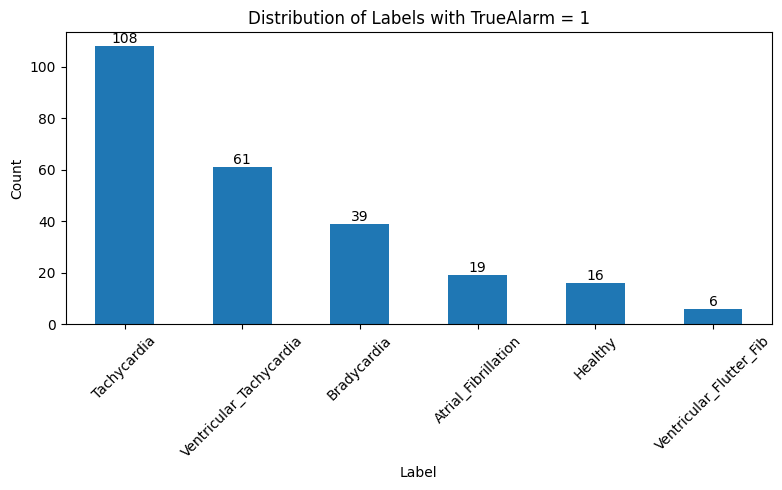

In [34]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = df_filtered.loc[df_filtered["TrueAlarm"] == 1, "Label"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels with TrueAlarm = 1")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


## Quick-Access Functions

In [35]:
import scipy.signal as signal

# For downsampling 250 Hz to 125 Hz for consistency
def downsample(ecg_signal, original_fs=250, target_fs=125):
    if original_fs == target_fs:
        return ecg_signal  # No downsampling needed
    
    # Design a low-pass filter (FIR or IIR)
    nyquist = target_fs / 2  # Nyquist frequency for new sampling rate
    b, a = signal.butter(4, nyquist / (original_fs / 2), btype='low', analog=False)

    # Apply filter
    filtered_signal = signal.filtfilt(b, a, ecg_signal)

    # Downsample (take every 2nd sample)
    downsampled_signal = filtered_signal[::2]

    return downsampled_signal

def standardize(data):
    #return ( data - np.mean(data) ) / np.std(data)
    return data

def getWaveform(label, index, sampleType, startPoint=0, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        return_signal=pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+int(duration/2)]
        pass
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values[startPoint:startPoint+duration]
        except:
            return_signal = pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values[startPoint:startPoint+duration]
        
        return_signal=downsample(return_signal)
    return standardize(return_signal)

def getWaveforms(label, index, sampleType, duration=1024, trueAlarm=1):
    if(label=="Atrial_Fibrillation" or label=="Healthy"):
        fullWaveform = standardize(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values)
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    else:
        if(sampleType=="ECG"):
            sampleType="II"
        elif(sampleType=="PPG"):
            sampleType="PLETH"
        try:
            fullWaveform = standardize(downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])[sampleType].values))
        except:
            fullWaveform = standardize(downsample(pd.read_csv(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm), "Path"].values[index])["V"].values))
        periodsList=[]
        for i in range(int(np.floor(len(fullWaveform)/duration))):
            periodsList.append(fullWaveform[i*duration:(i*duration)+duration])
    return periodsList

def get_num_waves(label, trueAlarm=1):
    return len(df_filtered.loc[(df_filtered["Label"]==label) & (df_filtered["TrueAlarm"]==trueAlarm)].index)

# Feature Extraction

## Sarah's PPG Feature Extractor (PPG)

In [42]:
def extract_ppg_features(ppg_signal, label, sampling_rate=125):
    """Extracts features from an 8-second PPG segment."""
    peaks, _ = find_peaks(ppg_signal, height=0.5)
    valleys, _ = find_peaks(-ppg_signal, height=-0.5)

    std_ppg_signal=(ppg_signal-np.mean(ppg_signal))/(np.std(ppg_signal)+1e-8)
    
    systolic_amplitude = max(ppg_signal[peaks]) - min(ppg_signal[valleys]) if len(peaks) > 0 and len(valleys) > 0 else 0
    diastolic_amplitude = min(ppg_signal[valleys]) if len(valleys) > 0 else 0
    
    pulse_intervals = np.diff(peaks) / sampling_rate if len(peaks) > 1 else [0]
    peak_to_peak_interval = np.mean(pulse_intervals) if len(pulse_intervals) > 0 else 0
    
    systolic_time = np.mean(np.diff(peaks)) / sampling_rate if len(peaks) > 1 else 0
    diastolic_time = np.mean(np.diff(valleys)) / sampling_rate if len(valleys) > 1 else 0
    
    systolic_area = trapezoidal_rule(std_ppg_signal[peaks]) if len(peaks) > 0 else 0
    diastolic_area = trapezoidal_rule(std_ppg_signal[valleys]) if len(valleys) > 0 else 0
    
    half_max = np.max(ppg_signal) / 2
    above_half = np.where(ppg_signal > half_max)[0]
    fwhm = (above_half[-1] - above_half[0]) / sampling_rate if len(above_half) > 1 else 0
    
    return {
        'Systolic Amplitude': systolic_amplitude,
        'Diastolic Amplitude': diastolic_amplitude,
        'Systolic Area': systolic_area,
        'Diastolic Area': diastolic_area,
        'Systolic Time': systolic_time,
        'Diastolic Time': diastolic_time,
        'Pulse Interval': np.mean(pulse_intervals),
        'Peak-to-Peak Interval': peak_to_peak_interval,
        'Full Width Half Maximum': fwhm,
        'Label': label
    }

def trapezoidal_rule(signal):
    """Computes the integral using the trapezoidal rule."""
    if len(signal) < 2:
        return 0  # Cannot integrate a single point
    return np.trapz(signal)

## Noor's Feature Extractor (ECG)

In [43]:
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency
fs = 125

def getIntervals(points):
    intervals=[]
    for pi in range(len(points)-1):
            intervals.append(points[pi+1]-points[pi])
    return intervals

labels=[]
labels_passed=[]
groups=[]
groups_passed=[]

# ECG features
diff_median=[]
distance_median=[]
distance_std=[]
num_peaks=[]
num_valleys=[]
first_peak_freq=[]
second_peak_freq=[]
rr_median=[]
rr_std=[]
ss_median=[]
ss_std=[]

# PPG features
systolic_amp=[]
diastolic_amp=[]
systolic_area=[]
diastolic_area=[]
systolic_time=[]
diastolic_time=[]
pulse_interval=[]
pp_interval=[]
fwhm=[]

signals_ecg=[]
signals_ppg=[]

for label in df_filtered["Label"].unique():
    # Append true alarms
    for i in range(get_num_waves(label)):
        waveform_parts_ecg=getWaveforms(label, i, "ECG")
        waveform_parts_ppg=getWaveforms(label, i, "PPG")
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*[label])
        groups.extend(len(waveform_parts_ecg)*[label+str(i)])
    # Append false alarms
    for i in range(get_num_waves(label, 0)):
        waveform_parts_ecg=getWaveforms(label, 0, "ECG", trueAlarm=0)
        waveform_parts_ppg=getWaveforms(label, 0, "PPG", trueAlarm=0)
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*["Healthy"])
        groups.extend(len(waveform_parts_ecg)*["FalseAlarm"+str(i)])


for i in range(len(signals_ecg)):
    # Time-domain parameters
    N = len(signals_ecg[i])

    # Frequency-domain parameters
    yf = fft(signals_ecg[i])
    xf = fftfreq(N, 1 / fs)[:N // 2]
    yf_processed = 2.0 / N * np.abs(yf[:N // 2])

    # Detect peaks and valleys
    fft_peaks, _ = find_peaks(2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=0.75,
                          rel_height=0.5)
    
    fft_valleys, _ = find_peaks(-2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=1.5,
                          rel_height=0.5)
    # Time domain features
    td_peaks, _ = find_peaks(signals_ecg[i],
                          height=1, 
                          threshold=0.005, 
                          distance=0.3*fs,
                          prominence=0.2,
                          width=None,
                          rel_height=None)
    
    td_valleys, _ = find_peaks(-signals_ecg[i],
                          height=None, 
                          threshold=0.01, 
                          distance=0.3*fs,
                          prominence=0.4,
                          width=None,
                          rel_height=None)
    
    if(np.isnan(yf).any()): # Don't save anything if fft contains nan
        continue # go to next iteration
        
    diff_median.append(np.median(2.0/N * np.abs(yf[:N//2])[fft_peaks])-np.median(2.0/N * np.abs(yf[:N//2])[fft_valleys]))
    num_peaks.append(len(fft_peaks))
    num_valleys.append(len(fft_valleys))
    fft_intervals=getIntervals(xf[fft_peaks]) # find intervals between every two peaks
    distance_median.append(np.median(fft_intervals))
    distance_std.append(np.std(fft_intervals))
    try:
        first_peak_freq.append(xf[fft_peaks[0]])
    except:
        first_peak_freq.append(0)
    try:
        second_peak_freq.append(xf[fft_peaks[1]])
    except:
        second_peak_freq.append(0)
    
    labels_passed.append(labels[i])
    groups_passed.append(groups[i])

    td_rr=getIntervals(td_peaks)
    td_ss=getIntervals(td_valleys)
    rr_median.append(np.median(td_rr))
    rr_std.append(np.std(td_rr))
    ss_median.append(np.median(td_ss))
    ss_std.append(np.std(td_ss))

    # PPG
    ppg_features=extract_ppg_features(signals_ppg[i], labels[i], sampling_rate=125)
    systolic_amp.append(ppg_features["Systolic Amplitude"])
    diastolic_amp.append(ppg_features["Diastolic Amplitude"])
    systolic_area.append(ppg_features["Systolic Area"])
    diastolic_area.append(ppg_features["Diastolic Area"])
    systolic_time.append(ppg_features["Systolic Time"])
    diastolic_time.append(ppg_features["Diastolic Time"])
    pulse_interval.append(ppg_features["Pulse Interval"])
    pp_interval.append(ppg_features["Peak-to-Peak Interval"])
    fwhm.append(ppg_features["Full Width Half Maximum"])

samples_df=pd.DataFrame({"Labels": labels_passed, "Groups": groups_passed, "diff_median":diff_median, 
                         "dist_median": distance_median, "dist_std": distance_std, "num_peaks":num_peaks, 
                         "num_valleys":num_valleys, "first_peak_freq":first_peak_freq, "second_peak_freq":second_peak_freq,
                         "rr_median": rr_median, "rr_std": rr_std, "ss_median": ss_median, "ss_std": ss_std,
                        "systolic_amp":systolic_amp, "diastolic_amp":diastolic_amp, "systolic_area":systolic_area,
                        "diastolic_area":diastolic_area, "systolic_time":systolic_time, "diastolic_time":diastolic_time,
                        "pulse_interval":pulse_interval, "pp_interval":pp_interval, "fwhm":fwhm})
samples_df=samples_df.dropna().reset_index(drop=True)
#samples_df.drop("diastolic_area", axis=1, inplace=True)
samples_df


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
<ipython-input-42-d225ef71ac33>:21: RuntimeWarning: invalid value encountered in greater
  above_half = np.where(ppg_signal > half_max)[0]


,Labels,Groups,diff_median,dist_median,dist_std,num_peaks,num_valleys,first_peak_freq,second_peak_freq,rr_median,...,ss_std,systolic_amp,diastolic_amp,systolic_area,diastolic_area,systolic_time,diastolic_time,pulse_interval,pp_interval,fwhm
0,Ventricular_Tachycardia,Ventricular_Tachycardia0,18.248115,0.366211,0.147586,173,61,0.488281,1.342773,41.0,...,10.434069,0.000000,0.000000,-12.648173,0.000000,0.103077,0.000000,0.103077,0.103077,7.344
1,Ventricular_Tachycardia,Ventricular_Tachycardia0,11.671329,0.488281,0.256410,112,75,0.854492,1.342773,49.0,...,12.476645,9190.259274,-2.885595,4.988498,-53.028125,0.114000,0.035130,0.114000,0.114000,8.096
2,Ventricular_Tachycardia,Ventricular_Tachycardia0,14.258346,0.488281,0.216090,119,74,0.488281,0.854492,42.0,...,12.588575,0.000000,0.000000,3.823473,0.000000,0.117091,0.000000,0.117091,0.117091,8.184
3,Ventricular_Tachycardia,Ventricular_Tachycardia0,7.505482,0.488281,0.256050,124,77,0.366211,0.732422,49.0,...,12.557153,0.000000,0.000000,21.707967,0.000000,0.093810,0.000000,0.093810,0.093810,7.600
4,Ventricular_Tachycardia,Ventricular_Tachycardia0,11.444011,0.488281,0.200153,133,82,0.732422,1.098633,42.0,...,12.850195,0.000000,0.000000,9.038534,0.000000,0.052416,0.000000,0.052416,0.052416,5.472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21317,Healthy,Healthy15,0.004485,0.976562,0.504369,55,45,0.244141,1.098633,77.5,...,32.252476,0.551320,0.253177,22.374914,-17.942630,0.620667,0.463059,0.620667,0.620667,8.184
21318,Healthy,Healthy15,0.003656,1.220703,0.533070,58,47,0.244141,0.732422,78.0,...,49.146041,0.539589,0.254154,22.096484,-15.649359,0.623333,0.574769,0.623333,0.623333,8.000
21319,Healthy,Healthy15,0.005698,1.220703,0.746514,59,44,0.244141,0.610352,77.0,...,23.271442,0.463343,0.242424,22.497276,-18.694399,0.619333,0.475294,0.619333,0.619333,8.080
21320,Healthy,Healthy15,0.008470,1.586914,0.459995,45,40,0.244141,0.488281,77.0,...,31.000806,0.611926,0.240469,22.473088,-17.312340,0.617231,0.508267,0.617231,0.617231,8.184


## Plot Number of Samples Per Condition

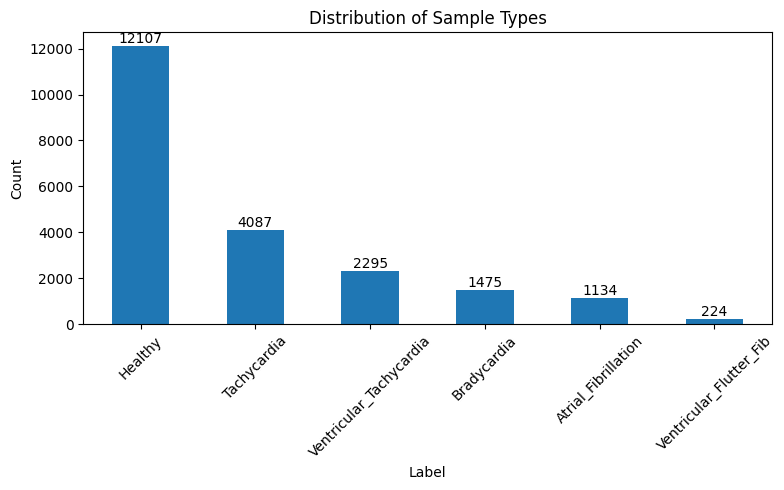

In [44]:
# Count the occurrences of each label
label_counts = samples_df["Labels"].value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()


# Training: Combined Model

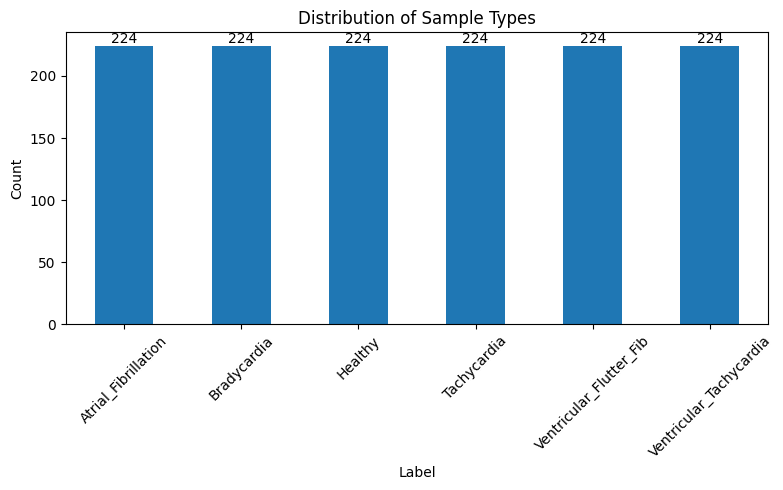


################################################################

STATUS REPORT:
Iteration 1 of 20 runs completed
Test_Score: 0.617, Mean_Score: 0.617, STD: 0.0

################################################################
 

################################################################

STATUS REPORT:
Iteration 2 of 20 runs completed
Test_Score: 0.694, Mean_Score: 0.656, STD: 0.03839914904932856

################################################################
 

################################################################

STATUS REPORT:
Iteration 3 of 20 runs completed
Test_Score: 0.645, Mean_Score: 0.652, STD: 0.031788003669862896

################################################################
 

################################################################

STATUS REPORT:
Iteration 4 of 20 runs completed
Test_Score: 0.608, Mean_Score: 0.641, STD: 0.033565408647494646

################################################################
 

#############################

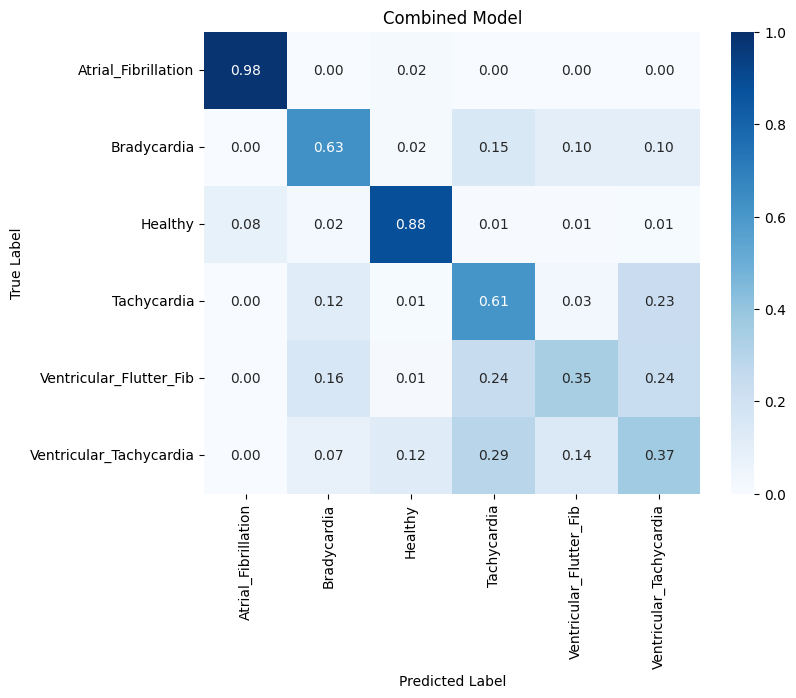

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

max_num_samples=224

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':max_num_samples, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
groups=Xg["Groups"]

# Count the occurrences of each label
label_counts = y.value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()

num_classes=len(samples_df["Labels"].unique())
accumulated_cm=np.zeros((num_classes, num_classes))

scores=[]
num_trials=20

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(X, groups=groups)
    train_inds, test_inds=next(split)

    train_X=X.iloc[train_inds]
    test_X=X.iloc[test_inds]
    train_y=y.iloc[train_inds]
    test_y=y.iloc[test_inds]
    
    model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    model.fit(train_X, train_y)
    yhat=model.predict(test_X)
    acc = accuracy_score(test_y, yhat)
    
    scores.append(acc)

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Mean_Score: {np.mean(scores):.3f}, STD: {np.std(scores)}')
    print("\n################################################################\n ")

    accumulated_cm += confusion_matrix(test_y, yhat, labels=model.classes_)

final_cm = accumulated_cm.astype('float') / accumulated_cm.sum(axis=1, keepdims=True)

# Plot final confusion matrix
#plot_confusion_matrix(y_true=test_y, y_pred=yhat, class_names=model.classes_, normalize=False)
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_, vmin=0, vmax=1)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Combined Model')
plt.show()

## Feature elimination

In [55]:
model = RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7, max_depth=10)
model.fit(X, y)

importances=pd.DataFrame({"Features": model.feature_names_in_, "Importances": model.feature_importances_}).sort_values(by="Importances", ascending=False)
importances.to_excel("RF_Importances.xlsx")

display(importances)

cutoff=0.07
high_importance_features=importances.loc[importances["Importances"]>=cutoff, "Features"].values

X_important = X[high_importance_features]
important_samples_df=pd.concat([X_important,y], axis=1)
print("Atrial_Fibrillation")
display(important_samples_df.loc[important_samples_df["Labels"]=="Atrial_Fibrillation"].describe())
print("Bradycardia")
display(important_samples_df.loc[important_samples_df["Labels"]=="Bradycardia"].describe())
print("Healthy")
display(important_samples_df.loc[important_samples_df["Labels"]=="Healthy"].describe())
print("Tachycardia")
display(important_samples_df.loc[important_samples_df["Labels"]=="Tachycardia"].describe())
print("Ventricular_Flutter_Fib")
display(important_samples_df.loc[important_samples_df["Labels"]=="Ventricular_Flutter_Fib"].describe())
print("Ventricular_Tachycardia")
display(important_samples_df.loc[important_samples_df["Labels"]=="Ventricular_Tachycardia"].describe())

,Features,Importances
0,diff_median,0.186910
13,systolic_area,0.136724
9,ss_median,0.115351
8,rr_std,0.071640
15,systolic_time,0.059399
12,diastolic_amp,0.057035
17,pulse_interval,0.056251
18,pp_interval,0.055252
10,ss_std,0.040325
2,dist_std,0.032625


Atrial_Fibrillation


,diff_median,systolic_area,ss_median,rr_std
count,224.000000,224.000000,224.000000,224.000000
mean,0.007891,15.825582,139.580357,31.082063
std,0.003794,3.530208,118.469738,36.668036
min,0.003815,3.827463,56.000000,0.000000
25%,0.005339,13.950488,77.000000,12.183984
50%,0.006569,15.668324,98.500000,18.675688
75%,0.008695,18.251473,144.625000,31.402723
max,0.020651,24.568912,773.000000,222.500000


Bradycardia


,diff_median,systolic_area,ss_median,rr_std
count,224.000000,224.000000,224.000000,224.000000
mean,17.386375,-24.131285,50.497768,18.206557
std,16.931192,50.630833,6.093350,14.123012
min,-0.945039,-150.114357,40.000000,0.480233
25%,6.086843,-64.089930,46.000000,9.951561
50%,11.480831,-14.379799,49.000000,13.790735
75%,24.042026,10.222156,54.000000,23.748120
max,122.909638,102.802627,73.000000,102.604452


...

,diff_median,systolic_area,ss_median,rr_std
count,224.000000,224.000000,224.000000,224.000000
mean,19.424694,6.974762,53.542411,8.394928
std,14.640908,27.015985,9.060298,5.332159
min,1.185077,-94.696521,39.000000,0.316228
25%,8.561668,-5.422342,48.000000,5.230221
50%,16.011429,10.333112,51.000000,8.285998
75%,25.737041,21.850183,59.000000,11.332315
max,102.329891,106.350701,77.000000,44.969260


Ventricular_Flutter_Fib


,diff_median,systolic_area,ss_median,rr_std
count,224.000000,224.000000,224.000000,224.000000
mean,10.860150,68.675441,54.149554,18.695382
std,23.773473,86.751862,7.777091,22.385322
min,-0.985656,-17.627953,40.500000,0.000000
25%,3.655968,22.397749,48.000000,10.661256
50%,7.647482,30.188653,54.000000,12.688839
75%,12.025944,38.170113,59.000000,20.592900
max,282.884711,243.721393,79.000000,228.870172


Ventricular_Tachycardia


,diff_median,systolic_area,ss_median,rr_std
count,224.000000,224.000000,224.000000,224.000000
mean,18.056558,10.716443,52.662946,12.191095
std,18.027771,22.658235,10.115765,8.514613
min,0.155742,-70.477265,39.000000,0.000000
25%,6.340580,0.279222,45.000000,7.268692
50%,11.215869,17.002572,49.250000,11.238297
75%,23.981536,22.837017,57.625000,15.732461
max,89.880856,66.115507,78.000000,60.297641


In [47]:
X_important.describe()

,diff_median,systolic_area,ss_median,rr_std,pp_interval,pulse_interval
count,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000,1344.000000
mean,12.226165,16.530403,70.440848,16.865245,0.303411,0.303411
std,16.824544,51.391193,59.108852,22.651084,0.287731,0.287731
min,-0.985656,-150.114357,39.000000,0.000000,0.000000,0.000000
25%,2.832428,6.902689,48.000000,7.355409,0.086508,0.086508
50%,7.653186,17.043344,56.000000,11.548337,0.191179,0.191179
75%,14.928354,23.634034,72.000000,18.428280,0.445176,0.445176
max,282.884711,243.721393,773.000000,245.000000,1.578000,1.578000


In [50]:
max_num_samples=224

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':185, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
groups=Xg["Groups"]

exported_data=X_important.copy()
exported_data["y"]=y

exported_data.to_csv("Important_Features_Data.csv")

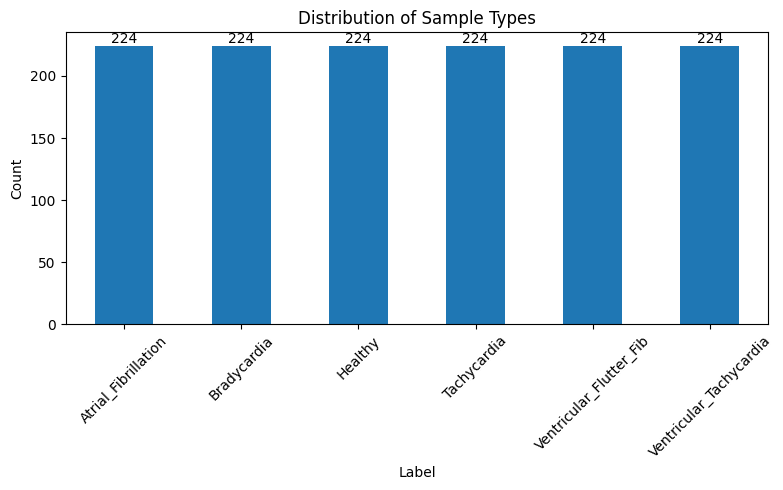


################################################################

STATUS REPORT:
Iteration 1 of 20 runs completed
Test_Score: 0.609, Mean_Score: 0.609, STD: 0.0

################################################################
 

################################################################

STATUS REPORT:
Iteration 2 of 20 runs completed
Test_Score: 0.670, Mean_Score: 0.639, STD: 0.030514559234144367

################################################################
 

################################################################

STATUS REPORT:
Iteration 3 of 20 runs completed
Test_Score: 0.640, Mean_Score: 0.639, STD: 0.024915689832892284

################################################################
 

################################################################

STATUS REPORT:
Iteration 4 of 20 runs completed
Test_Score: 0.597, Mean_Score: 0.629, STD: 0.02840262035755856

################################################################
 

#############################

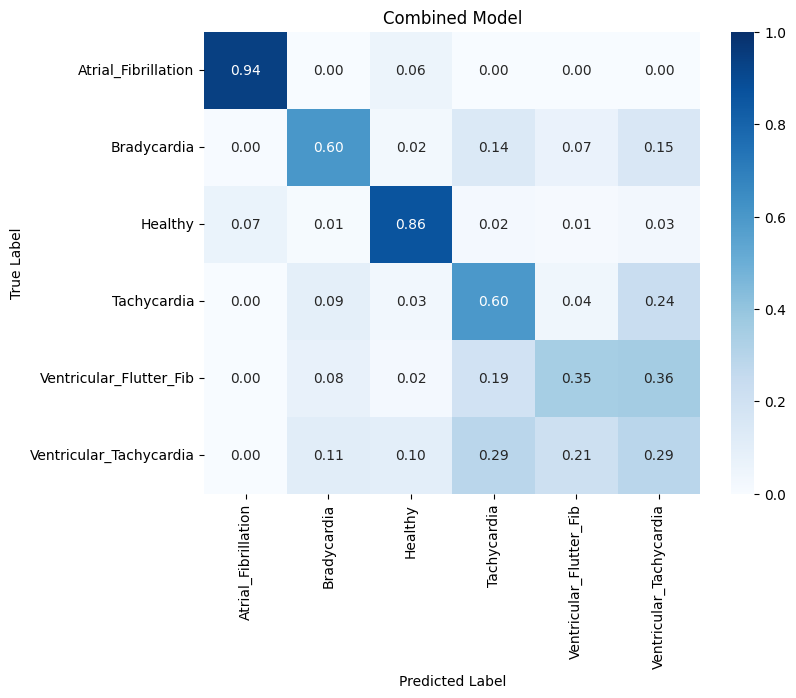

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

max_num_samples=224

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':max_num_samples, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
X_important=X[high_importance_features]
groups=Xg["Groups"]

# Count the occurrences of each label
label_counts = y.value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()

num_classes=len(samples_df["Labels"].unique())
accumulated_cm=np.zeros((num_classes, num_classes))

scores=[]
num_trials=20

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(X_important, groups=groups)
    train_inds, test_inds=next(split)

    train_X=X_important.iloc[train_inds]
    test_X=X_important.iloc[test_inds]
    train_y=y.iloc[train_inds]
    test_y=y.iloc[test_inds]
    
    model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    model.fit(train_X, train_y)
    yhat=model.predict(test_X)
    acc = accuracy_score(test_y, yhat)
    
    scores.append(acc)

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Mean_Score: {np.mean(scores):.3f}, STD: {np.std(scores)}')
    print("\n################################################################\n ")

    accumulated_cm += confusion_matrix(test_y, yhat, labels=model.classes_)

final_cm = accumulated_cm.astype('float') / accumulated_cm.sum(axis=1, keepdims=True)

# Plot final confusion matrix
#plot_confusion_matrix(y_true=test_y, y_pred=yhat, class_names=model.classes_, normalize=False)
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_, vmin=0, vmax=1)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Combined Model')
plt.show()

In [ ]:
important_samples_df.loc[important_samples_df["Labels"]=="Atrial_Fibrillation"].drop("Labels", axis=1)
model.predict(important_samples_df.loc[important_samples_df["Labels"]=="Atrial_Fibrillation"].drop("Labels", axis=1))

In [57]:
import numpy as np
from sklearn.tree import _tree
from sklearn.ensemble import RandomForestClassifier
import joblib

def tree_to_code(tree, feature_names, tree_index=0, file=None):
    """Recursively converts a decision tree to a set of if-else rules and writes it to a file."""
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
    
    def recurse(node, depth):
        indent = "    " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            file.write(f"{indent}if ({name} <= {threshold}) {{\n")
            recurse(tree_.children_left[node], depth + 1)
            file.write(f"{indent}}} else {{\n")
            recurse(tree_.children_right[node], depth + 1)
            file.write(f"{indent}}}\n")
        else:
            file.write(f"{indent}votes[{tree_index}] = {np.argmax(tree_.value[node])};\n")

    file.write(f"// Decision rules for tree {tree_index}\n")
    recurse(0, 1)

max_num_samples=185

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]
rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':max_num_samples, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
Xg.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)
X=Xg.drop(["Groups"], axis=1)
X_important=X[high_importance_features]
model = RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7, max_depth=10)
model.fit(X_important, y)

feature_names=""
for feature in model.feature_names_in_:
    feature_names+="float "+feature+", "

feature_names=feature_names[0:-2]

with open("random_forest.cpp", "w") as file:
    file.write("#include <vector>\n")
    file.write("using namespace std;\n\n")
    file.write("int random_forest_predict("+feature_names+") {\n")
    file.write(f"    int votes[{len(model.estimators_)}] = {{0}};\n")
    
    for i, tree in enumerate(model.estimators_):
        #file.write(f"    votes[{i}] = (\n")
        tree_to_code(tree, model.feature_names_in_, tree_index=i, file=file)
        #file.write("    );\n")
    
    file.write("    // Majority voting\n")
    file.write(f"    int class_counts[{model.n_classes_}] = {{0}};\n")
    file.write(f"    for (int i = 0; i < {len(model.estimators_)}; i++) {{\n")
    file.write("        class_counts[votes[i]]++;\n")
    file.write("    }\n")
    file.write("    int predicted_class = 0;\n")
    file.write(f"    for (int i = 1; i < {model.n_classes_}; i++) {{\n")
    file.write("        if (class_counts[i] > class_counts[predicted_class]) {\n")
    file.write("            predicted_class = i;\n")
    file.write("        }\n")
    file.write("    }\n")
    file.write("    return predicted_class;\n")
    file.write("}\n")


In [ ]:
model.classes_

# Training: Stacked Model

In [ ]:
samples_df.columns

1000 samples

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

max_num_samples=1000

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]

rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':185, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
X=Xg.drop(["Groups"], axis=1)
groups=Xg["Groups"]

X_ecg=X.drop(['systolic_amp',
       'diastolic_amp', 'systolic_time',
       'diastolic_time', 'pulse_interval', 'pp_interval', 'fwhm'], axis=1)
X_ppg=X.drop(['diff_median', 'dist_median', 'dist_std',
       'num_peaks', 'num_valleys', 'first_peak_freq', 'second_peak_freq',
       'rr_median', 'rr_std', 'ss_median', 'ss_std'], axis=1)

X.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)

# Count the occurrences of each label
label_counts = y.value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()

num_classes=len(samples_df["Labels"].unique())
accumulated_cm=np.zeros((num_classes, num_classes))

scores=[]
num_trials=20

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(X, groups=groups)
    train_inds, test_inds=next(split)

    train_X_ecg=X_ecg.iloc[train_inds]
    test_X_ecg=X_ecg.iloc[test_inds]
    train_X_ppg=X_ppg.iloc[train_inds]
    test_X_ppg=X_ppg.iloc[test_inds]
    train_y=y.iloc[train_inds]
    test_y=y.iloc[test_inds]

    train_X_ecg.reset_index(inplace=True, drop=True)
    test_X_ecg.reset_index(inplace=True, drop=True)
    train_X_ppg.reset_index(inplace=True, drop=True)
    test_X_ppg.reset_index(inplace=True, drop=True)
    train_y.reset_index(inplace=True, drop=True)
    test_y.reset_index(inplace=True, drop=True)
    
    ecg_model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    ppg_model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    
    #####################################################
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds=np.zeros((len(train_y), 2))
    test_preds = np.zeros((len(test_y), 2))

    for train_idx, valid_idx in kf.split(train_y):
        X_tr_ecg, X_val_ecg = train_X_ecg.iloc[train_idx], train_X_ecg.iloc[valid_idx]
        X_tr_ppg, X_val_ppg = train_X_ppg.iloc[train_idx], train_X_ppg.iloc[valid_idx]
        y_tr, y_val = train_y.iloc[train_idx], train_y.iloc[valid_idx]
        
        # Train both Random Forests
        ecg_model.fit(X_tr_ecg, y_tr)
        ppg_model.fit(X_tr_ppg, y_tr)
        
        # Store OOF predictions
        oof_preds[valid_idx, 0] = ecg_model.predict_proba(X_val_ecg)[:, 1]  # Class 1 prob
        oof_preds[valid_idx, 1] = ppg_model.predict_proba(X_val_ppg)[:, 1]

        # Accumulate test set predictions (average over folds)
        test_preds[:, 0] += ecg_model.predict_proba(test_X_ecg)[:, 1] / kf.get_n_splits()
        test_preds[:, 1] += ppg_model.predict_proba(test_X_ppg)[:, 1] / kf.get_n_splits()
    #####################################################
    meta_model = LogisticRegression()
    meta_model.fit(oof_preds, train_y)
    
    yhat=meta_model.predict(test_preds)
    yhat_ecg=ecg_model.predict(test_X_ecg)
    yhat_ppg=ppg_model.predict(test_X_ppg)
    acc = accuracy_score(test_y, yhat)
    
    scores.append(acc)

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Mean_Score: {np.mean(scores):.3f}, STD: {np.std(scores)}')
    print("\n################################################################\n ")

    accumulated_cm += confusion_matrix(test_y, yhat, labels=model.classes_)
    accumulated_cm_ecg += confusion_matrix(test_y, yhat_ecg, labels=model.classes_)
    accumulated_cm_ppg += confusion_matrix(test_y, yhat_ppg, labels=model.classes_)

final_cm = accumulated_cm.astype('float') / accumulated_cm.sum(axis=1, keepdims=True)
final_cm_ecg = accumulated_cm_ecg.astype('float') / accumulated_cm_ecg.sum(axis=1, keepdims=True)
final_cm_ppg = accumulated_cm_ppg.astype('float') / accumulated_cm_ppg.sum(axis=1, keepdims=True)

# Plot three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cm, title in zip(
    axes,
    [final_cm_ecg, final_cm_ppg, final_cm],
    ["ECG Model", "PPG Model", "Stacked Model"]
):
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, xticklabels=meta_model.classes_, yticklabels=meta_model.classes_, vmin=0, vmax=1)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

plt.tight_layout()
plt.show()

Getting features of one patient

In [ ]:
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency
fs = 125

def getIntervals(points):
    intervals=[]
    for pi in range(len(points)-1):
            intervals.append(points[pi+1]-points[pi])
    return intervals

labels=[]
labels_passed=[]
groups=[]
groups_passed=[]
chunk_index=[]

# ECG features
diff_median=[]
distance_median=[]
distance_std=[]
num_peaks=[]
num_valleys=[]
first_peak_freq=[]
second_peak_freq=[]
rr_median=[]
rr_std=[]
ss_median=[]
ss_std=[]

# PPG features
systolic_amp=[]
diastolic_amp=[]
systolic_area=[]
diastolic_area=[]
systolic_time=[]
diastolic_time=[]
pulse_interval=[]
pp_interval=[]
fwhm=[]

signals_ecg=[]
signals_ppg=[]

for label in df_filtered["Label"].unique():
    # Append true alarms
    for i in range(get_num_waves(label)):
        waveform_parts_ecg=getWaveforms(label, i, "ECG")
        waveform_parts_ppg=getWaveforms(label, i, "PPG")
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*[label])
        groups.extend(len(waveform_parts_ecg)*[label+str(i)])
    # Append false alarms
    for i in range(get_num_waves(label, 0)):
        waveform_parts_ecg=getWaveforms(label, 0, "ECG", trueAlarm=0)
        waveform_parts_ppg=getWaveforms(label, 0, "PPG", trueAlarm=0)
        signals_ecg.extend(waveform_parts_ecg)
        signals_ppg.extend(waveform_parts_ppg)
        labels.extend(len(waveform_parts_ecg)*["Healthy"])
        groups.extend(len(waveform_parts_ecg)*["FalseAlarm"+str(i)])

chunk_i=0
for i in range(len(signals_ecg)):
    if(i!=0 and groups[i-1]!=groups[i]):
        chunk_i=0
    # Time-domain parameters
    N = len(signals_ecg[i])
    #print(np.count_nonzero(np.isnan(signals_ecg[i])))

    # Frequency-domain parameters
    yf = fft(signals_ecg[i])
    xf = fftfreq(N, 1 / fs)[:N // 2]
    yf_processed = 2.0 / N * np.abs(yf[:N // 2])

    # Detect peaks and valleys
    fft_peaks, _ = find_peaks(2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=0.75,
                          rel_height=0.5)
    
    fft_valleys, _ = find_peaks(-2.0/N * np.abs(yf[0:N//2]),
                          height=None, 
                          threshold=None, 
                          distance=None,
                          prominence=0.001,
                          width=1.5,
                          rel_height=0.5)
    # Time domain features
    td_peaks, _ = find_peaks(signals_ecg[i],
                          height=1, 
                          threshold=0.005, 
                          distance=0.3*fs,
                          prominence=0.2,
                          width=None,
                          rel_height=None)
    
    td_valleys, _ = find_peaks(-signals_ecg[i],
                          height=None, 
                          threshold=0.01, 
                          distance=0.3*fs,
                          prominence=0.4,
                          width=None,
                          rel_height=None)
    
    if(np.isnan(yf).any()): # Don't save anything if fft contains nan
        #print(np.count_nonzero(~np.isnan(yf)))
        continue # go to next iteration

    else:
        chunk_index.append(chunk_i)

    chunk_i+=1
        
    diff_median.append(np.median(2.0/N * np.abs(yf[:N//2])[fft_peaks])-np.median(2.0/N * np.abs(yf[:N//2])[fft_valleys]))
    num_peaks.append(len(fft_peaks))
    num_valleys.append(len(fft_valleys))
    fft_intervals=getIntervals(xf[fft_peaks]) # find intervals between every two peaks
    distance_median.append(np.median(fft_intervals))
    distance_std.append(np.std(fft_intervals))
    try:
        first_peak_freq.append(xf[fft_peaks[0]])
    except:
        first_peak_freq.append(0)
    try:
        second_peak_freq.append(xf[fft_peaks[1]])
    except:
        second_peak_freq.append(0)
    
    labels_passed.append(labels[i])
    groups_passed.append(groups[i])

    td_rr=getIntervals(td_peaks)
    td_ss=getIntervals(td_valleys)
    rr_median.append(np.median(td_rr))
    rr_std.append(np.std(td_rr))
    ss_median.append(np.median(td_ss))
    ss_std.append(np.std(td_ss))

    # PPG
    ppg_features=extract_ppg_features(signals_ppg[i], labels[i], sampling_rate=125)
    systolic_amp.append(ppg_features["Systolic Amplitude"])
    diastolic_amp.append(ppg_features["Diastolic Amplitude"])
    systolic_area.append(ppg_features["Systolic Area"])
    diastolic_area.append(ppg_features["Diastolic Area"])
    systolic_time.append(ppg_features["Systolic Time"])
    diastolic_time.append(ppg_features["Diastolic Time"])
    pulse_interval.append(ppg_features["Pulse Interval"])
    pp_interval.append(ppg_features["Peak-to-Peak Interval"])
    fwhm.append(ppg_features["Full Width Half Maximum"])

samples_df=pd.DataFrame({"Labels": labels_passed, "Groups": groups_passed, "ChunkIdx": chunk_index, "diff_median":diff_median, 
                         "dist_median": distance_median, "dist_std": distance_std, "num_peaks":num_peaks, 
                         "num_valleys":num_valleys, "first_peak_freq":first_peak_freq, "second_peak_freq":second_peak_freq,
                         "rr_median": rr_median, "rr_std": rr_std, "ss_median": ss_median, "ss_std": ss_std,
                        "systolic_amp":systolic_amp, "diastolic_amp":diastolic_amp, "systolic_area":systolic_area,
                        "diastolic_area":diastolic_area, "systolic_time":systolic_time, "diastolic_time":diastolic_time,
                        "pulse_interval":pulse_interval, "pp_interval":pp_interval, "fwhm":fwhm})
samples_df=samples_df.dropna().reset_index(drop=True)
#samples_df.drop("diastolic_area", axis=1, inplace=True)
samples_df


In [ ]:
chunks_features=samples_df.loc[samples_df["Groups"]=="Ventricular_Flutter_Fib0"][["ChunkIdx", "rr_std", "rr_median", "diastolic_time", "dist_std", "num_peaks", "num_valleys"]].reset_index(drop=True)
chunks_features

In [ ]:
chunk_index_col=[]
dataset=pd.read_csv(df_filtered.loc[df_filtered["Sample"]=="f450s","Path"].values[0])
target_len=len(dataset.index)
hit_max=False
for i in range(int(np.ceil(target_len/1024))):
    for point in range(1024):
        if(hit_max):
            break
        chunk_index_col.append(i)
        hit_max=len(chunk_index_col)>=target_len

print(len(chunk_index_col))

In [ ]:
df=pd.read_csv(df_filtered.loc[df_filtered["Sample"]=="f450s","Path"].values[0])
df_export=pd.DataFrame({"ECG": df["II"].values, "PPG": df["PLETH"].values, "ChunkIdx": chunk_index_col})
df_export=df_export.loc[df_export["ChunkIdx"].isin(chunks_features["ChunkIdx"].values)].copy().drop("ChunkIdx", axis=1)
display(df_export)
df_export.to_csv("f450s.csv")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define two arrays
data1 = np.random.normal(loc=5, scale=1.5, size=100)
data2 = np.random.normal(loc=7, scale=2, size=100)

# Combine data into a list
all_data = [data1, data2]

# Create the violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=all_data)

# Customize plot
plt.xticks([0, 1], ['Dataset 1', 'Dataset 2'])
plt.ylabel('Values')
plt.yscale('log')  # Set log scale for y-axis
plt.title('Violin Plot of Two Datasets (Log Scale)')

# Show plot
plt.show()
185 samples

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler

max_num_samples=185

Xg=samples_df.drop(["Labels"], axis=1)
y=samples_df["Labels"]

rus = RandomUnderSampler(random_state=0, sampling_strategy={'Atrial_Fibrillation':max_num_samples, 'Bradycardia':max_num_samples, 'Healthy':max_num_samples, 'Tachycardia':max_num_samples,
 'Ventricular_Flutter_Fib':185, 'Ventricular_Tachycardia':max_num_samples})
Xg, y=rus.fit_resample(Xg, y)
X=Xg.drop(["Groups"], axis=1)
groups=Xg["Groups"]

X_ecg=X.drop(['systolic_amp',
       'diastolic_amp', 'systolic_area', 'diastolic_area', 'systolic_time',
       'diastolic_time', 'pulse_interval', 'pp_interval', 'fwhm'], axis=1)
X_ppg=X.drop(['diff_median', 'dist_median', 'dist_std',
       'num_peaks', 'num_valleys', 'first_peak_freq', 'second_peak_freq',
       'rr_median', 'rr_std', 'ss_median', 'ss_std'], axis=1)

X.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)

# Count the occurrences of each label
label_counts = y.value_counts()

# Plot as a bar plot
label_counts.plot(kind="bar", figsize=(8, 5))
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Sample Types")
plt.xticks(rotation=45)
plt.bar_label(plt.gca().containers[0])  # Add count labels on bars
plt.tight_layout()
plt.show()

num_classes=len(samples_df["Labels"].unique())
accumulated_cm=np.zeros((num_classes, num_classes))

scores=[]
num_trials=20

for i in range(num_trials):
    splitter=GroupShuffleSplit(test_size=0.2, random_state=i)
    split=splitter.split(X, groups=groups)
    train_inds, test_inds=next(split)

    train_X_ecg=X_ecg.iloc[train_inds]
    test_X_ecg=X_ecg.iloc[test_inds]
    train_X_ppg=X_ppg.iloc[train_inds]
    test_X_ppg=X_ppg.iloc[test_inds]
    train_y=y.iloc[train_inds]
    test_y=y.iloc[test_inds]

    train_X_ecg.reset_index(inplace=True, drop=True)
    test_X_ecg.reset_index(inplace=True, drop=True)
    train_X_ppg.reset_index(inplace=True, drop=True)
    test_X_ppg.reset_index(inplace=True, drop=True)
    train_y.reset_index(inplace=True, drop=True)
    test_y.reset_index(inplace=True, drop=True)
    
    ecg_model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    ppg_model=RandomForestClassifier(n_estimators=50, min_samples_split=4, min_samples_leaf=5, max_features=7,max_depth=10)
    
    #####################################################
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds=np.zeros((len(train_y), 2))
    test_preds = np.zeros((len(test_y), 2))

    for train_idx, valid_idx in kf.split(train_y):
        X_tr_ecg, X_val_ecg = train_X_ecg.iloc[train_idx], train_X_ecg.iloc[valid_idx]
        X_tr_ppg, X_val_ppg = train_X_ppg.iloc[train_idx], train_X_ppg.iloc[valid_idx]
        y_tr, y_val = train_y.iloc[train_idx], train_y.iloc[valid_idx]
        
        # Train both Random Forests
        ecg_model.fit(X_tr_ecg, y_tr)
        ppg_model.fit(X_tr_ppg, y_tr)
        
        # Store OOF predictions
        oof_preds[valid_idx, 0] = ecg_model.predict_proba(X_val_ecg)[:, 1]  # Class 1 prob
        oof_preds[valid_idx, 1] = ppg_model.predict_proba(X_val_ppg)[:, 1]

        # Accumulate test set predictions (average over folds)
        test_preds[:, 0] += ecg_model.predict_proba(test_X_ecg)[:, 1] / kf.get_n_splits()
        test_preds[:, 1] += ppg_model.predict_proba(test_X_ppg)[:, 1] / kf.get_n_splits()
    #####################################################
    meta_model = LogisticRegression()
    meta_model.fit(oof_preds, train_y)
    
    yhat=meta_model.predict(test_preds)
    yhat_ecg=ecg_model.predict(test_X_ecg)
    yhat_ppg=ppg_model.predict(test_X_ppg)
    acc = accuracy_score(test_y, yhat)
    
    scores.append(acc)

    print('\n################################################################\n\nSTATUS REPORT:')
    print(f'Iteration {i + 1} of {num_trials} runs completed')
    print(f'Test_Score: {acc:.3f}, Mean_Score: {np.mean(scores):.3f}, STD: {np.std(scores)}')
    print("\n################################################################\n ")

    accumulated_cm += confusion_matrix(test_y, yhat, labels=model.classes_)
    accumulated_cm_ecg += confusion_matrix(test_y, yhat_ecg, labels=model.classes_)
    accumulated_cm_ppg += confusion_matrix(test_y, yhat_ppg, labels=model.classes_)

final_cm = accumulated_cm.astype('float') / accumulated_cm.sum(axis=1, keepdims=True)
final_cm_ecg = accumulated_cm_ecg.astype('float') / accumulated_cm_ecg.sum(axis=1, keepdims=True)
final_cm_ppg = accumulated_cm_ppg.astype('float') / accumulated_cm_ppg.sum(axis=1, keepdims=True)

# Plot three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cm, title in zip(
    axes,
    [final_cm_ecg, final_cm_ppg, final_cm],
    ["ECG Model", "PPG Model", "Stacked Model"]
):
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, xticklabels=meta_model.classes_, yticklabels=meta_model.classes_, vmin=0, vmax=1)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title)

plt.tight_layout()
plt.show()